<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Handwritten_Digits_Project_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 بدء التدريب...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9125 - loss: 0.2990 - val_accuracy: 0.9581 - val_loss: 0.1388
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9567 - loss: 0.1464 - val_accuracy: 0.9677 - val_loss: 0.1023
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9673 - loss: 0.1082 - val_accuracy: 0.9751 - val_loss: 0.0886
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9718 - loss: 0.0908 - val_accuracy: 0.9754 - val_loss: 0.0790
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9761 - loss: 0.0758 - val_accuracy: 0.9766 - val_loss: 0.0756
✅ دقة النموذج: 97.66%


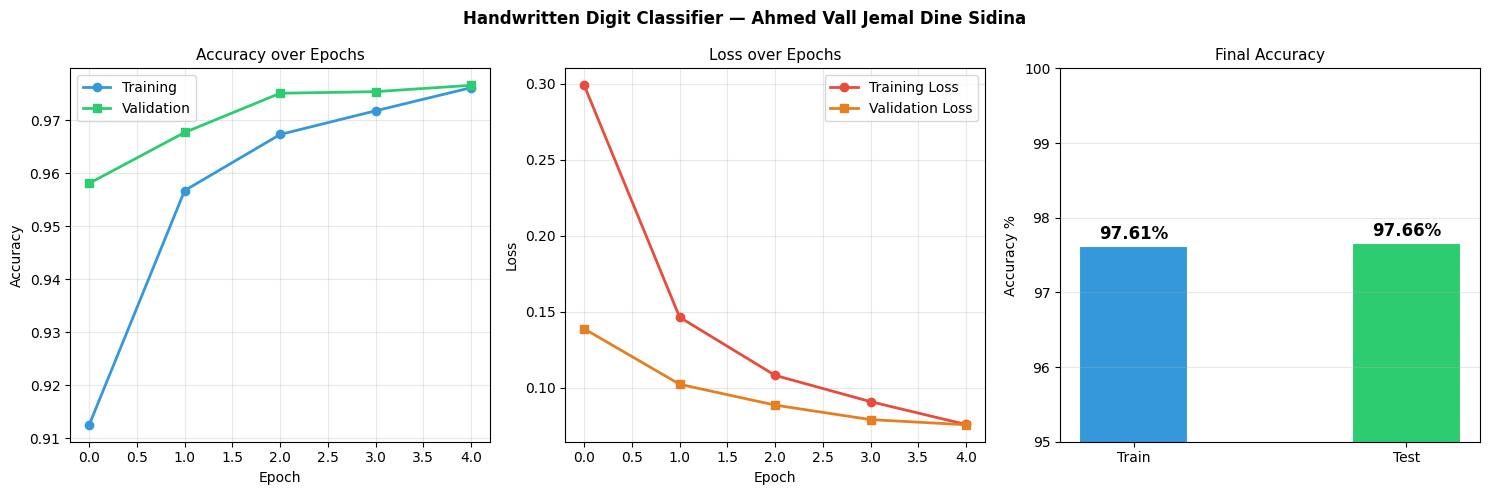

✅ تم حفظ الرسم البياني! الدقة: 97.66%


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# ── تحميل البيانات ──
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# ── بناء النموذج ──
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ── التدريب ──
print("🚀 بدء التدريب...")
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test, y_test), verbose=1)
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"✅ دقة النموذج: {accuracy*100:.2f}%")

# ── الرسم البياني ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Handwritten Digit Classifier — Ahmed Vall Jemal Dine Sidina',
             fontsize=12, fontweight='bold')

# 1️⃣ منحنى الدقة
axes[0].plot(history.history['accuracy'],
             color='#3498db', linewidth=2, marker='o', label='Training')
axes[0].plot(history.history['val_accuracy'],
             color='#2ecc71', linewidth=2, marker='s', label='Validation')
axes[0].set_title('Accuracy over Epochs', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2️⃣ منحنى الخسارة
axes[1].plot(history.history['loss'],
             color='#e74c3c', linewidth=2, marker='o', label='Training Loss')
axes[1].plot(history.history['val_loss'],
             color='#e67e22', linewidth=2, marker='s', label='Validation Loss')
axes[1].set_title('Loss over Epochs', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3️⃣ الدقة النهائية
bars = axes[2].bar(['Train', 'Test'],
               [history.history['accuracy'][-1]*100, accuracy*100],
               color=['#3498db', '#2ecc71'],
               edgecolor='white', linewidth=1.5, width=0.4)
for bar, val in zip(bars, [history.history['accuracy'][-1]*100, accuracy*100]):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center',
                 fontweight='bold', fontsize=12)
axes[2].set_title('Final Accuracy', fontsize=11)
axes[2].set_ylabel('Accuracy %')
axes[2].set_ylim(95, 100)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('handwritten_digits_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ تم حفظ الرسم البياني! الدقة: {accuracy*100:.2f}%")